In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os

project_path = "/content/drive/MyDrive/Colab Notebooks/computer vision/Ultralytics YOLO/pose estimation"
os.makedirs(project_path, exist_ok=True)

In [5]:
!pip install mediapipe opencv-python matplotlib

In [6]:
!pip install --upgrade mediapipe opencv-python matplotlib

In [7]:
!wget -q https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/latest/pose_landmarker_full.task

In [22]:
import os

save_dir = f"{project_path}/mediapipe_image_predictions"
os.makedirs(save_dir, exist_ok=True)

save_path = f"{save_dir}/image.jpg"

Saved: True
Path: /content/drive/MyDrive/Colab Notebooks/computer vision/Ultralytics YOLO/pose estimation/mediapipe_image_predictions/image.jpg


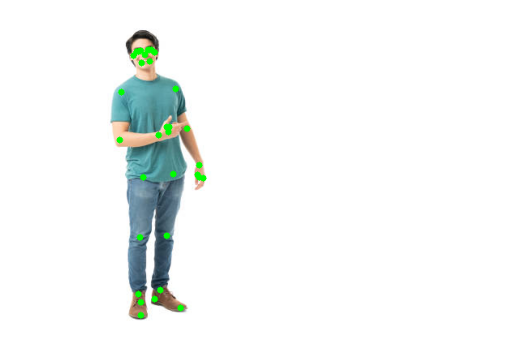

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Download model if not present
# !wget -q https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/latest/pose_landmarker_full.task

# Create base options
base_options = python.BaseOptions(
    model_asset_path="pose_landmarker_full.task"
)

options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    num_poses=1
)

detector = vision.PoseLandmarker.create_from_options(options)

# Load image
image = cv2.imread(f"{project_path}/image.jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 🔥 Correct MPImage creation
mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=image_rgb
)

# Run detection
result = detector.detect(mp_image)

# Draw landmarks
if result.pose_landmarks:
    for lm in result.pose_landmarks[0]:
        x = int(lm.x * image.shape[1])
        y = int(lm.y * image.shape[0])
        cv2.circle(image, (x, y), 4, (0, 255, 0), -1)

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")

success = cv2.imwrite(save_path, image)

print("Saved:", success)
print("Path:", save_path)

In [10]:
if result.pose_landmarks:
    landmarks = result.pose_landmarks[0]

    for idx, lm in enumerate(landmarks):
        print(
            f"{idx}: x={lm.x:.3f}, y={lm.y:.3f}, z={lm.z:.3f}, visibility={lm.visibility:.3f}"
        )

0: x=0.273, y=0.139, z=-0.408, visibility=1.000
1: x=0.278, y=0.124, z=-0.384, visibility=1.000
2: x=0.282, y=0.123, z=-0.384, visibility=1.000
3: x=0.285, y=0.123, z=-0.384, visibility=1.000
4: x=0.264, y=0.127, z=-0.390, visibility=1.000
5: x=0.259, y=0.128, z=-0.390, visibility=1.000
6: x=0.255, y=0.129, z=-0.390, visibility=1.000
7: x=0.292, y=0.130, z=-0.234, visibility=1.000
8: x=0.249, y=0.141, z=-0.262, visibility=1.000
9: x=0.283, y=0.159, z=-0.351, visibility=1.000
10: x=0.265, y=0.163, z=-0.359, visibility=1.000
11: x=0.333, y=0.240, z=-0.108, visibility=1.000
12: x=0.225, y=0.252, z=-0.199, visibility=1.000
13: x=0.357, y=0.362, z=-0.038, visibility=0.977
14: x=0.221, y=0.396, z=-0.264, visibility=0.995
15: x=0.382, y=0.472, z=-0.149, visibility=0.980
16: x=0.299, y=0.381, z=-0.417, visibility=0.991
17: x=0.389, y=0.512, z=-0.180, visibility=0.955
18: x=0.320, y=0.372, z=-0.459, visibility=0.977
19: x=0.382, y=0.510, z=-0.216, visibility=0.958
20: x=0.322, y=0.355, z=-0.464

In [13]:
def calculate_angle(a, b, c):
    a = np.array(a)
    b = np.array(b)
    c = np.array(c)

    ba = a - b
    bc = c - b

    cosine = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc))
    angle = np.degrees(np.arccos(cosine))
    return angle

if result.pose_landmarks:
    h, w, _ = image.shape
    lm = result.pose_landmarks[0]

    left_shoulder = [lm[11].x * w, lm[11].y * h]
    left_elbow = [lm[13].x * w, lm[13].y * h]
    left_wrist = [lm[15].x * w, lm[15].y * h]

    angle = calculate_angle(left_shoulder, left_elbow, left_wrist)
    print("Left elbow angle:", angle)

Left elbow angle: 176.4474492880418


In [27]:
import os

save_dir = f"{project_path}/mediapipe_video_predictions"
os.makedirs(save_dir, exist_ok=True)

save_path = f"{save_dir}/pose_output.mp4"

In [28]:
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import time

# Load model
base_options = python.BaseOptions(
    model_asset_path="pose_landmarker_full.task"
)

options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
    num_poses=1,
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5,
    min_tracking_confidence=0.5
)

detector = vision.PoseLandmarker.create_from_options(options)

# Open video
cap = cv2.VideoCapture(f"{project_path}/video1.mp4")

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(save_path, fourcc, fps, (width, height))

print("Saved:", out)
print("Path:", save_path)

start_time = time.time()

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # 🔥 Correct MP Image
    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=frame_rgb
    )

    # 🔥 IMPORTANT: timestamp must be in milliseconds
    timestamp_ms = int((time.time() - start_time) * 1000)

    result = detector.detect_for_video(mp_image, timestamp_ms)

    # Draw landmarks
    if result.pose_landmarks:
        for lm in result.pose_landmarks[0]:
            x = int(lm.x * width)
            y = int(lm.y * height)
            cv2.circle(frame, (x, y), 3, (0, 255, 0), -1)

    out.write(frame)

cap.release()
out.release()

print("Saved as pose_output.mp4")

Saved: < cv2.VideoWriter 0x786bbb5f9cb0>
Path: /content/drive/MyDrive/Colab Notebooks/computer vision/Ultralytics YOLO/pose estimation/mediapipe_video_predictions/pose_output.mp4
Saved as pose_output.mp4


In [29]:
# cap = cv2.VideoCapture(0)

# pose = mp_pose.Pose(
#     static_image_mode=False,
#     model_complexity=1,
#     min_detection_confidence=0.5,
#     min_tracking_confidence=0.5
# )

# while cap.isOpened():
#     ret, frame = cap.read()
#     if not ret:
#         break

#     image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#     results = pose.process(image_rgb)

#     if results.pose_landmarks:
#         mp_drawing.draw_landmarks(
#             frame,
#             results.pose_landmarks,
#             mp_pose.POSE_CONNECTIONS
#         )

#     cv2.imshow("Pose", frame)

#     if cv2.waitKey(1) & 0xFF == ord('q'):
#         break

# cap.release()
# cv2.destroyAllWindows()

In [30]:
# mp_pose.Pose(
#     static_image_mode=False,
#     model_complexity=0,  # 0=lite, 1=full, 2=heavy
#     enable_segmentation=False,
#     smooth_landmarks=True,
#     min_detection_confidence=0.5,
#     min_tracking_confidence=0.5
# )

In [ ]:
# 11 left_shoulder
# 13 left_elbow
# 15 left_wrist
# 23 left_hip
# 25 left_knee
# 27 left_ankle

In [31]:
# pose = mp_pose.Pose(enable_segmentation=True)

# if results.segmentation_mask is not None:
#     mask = results.segmentation_mask
#     plt.imshow(mask, cmap='gray')

In [41]:
import os

save_dir = f"{project_path}/mediapipe_image_predictions"
os.makedirs(save_dir, exist_ok=True)

save_path = f"{save_dir}/image1.jpg"

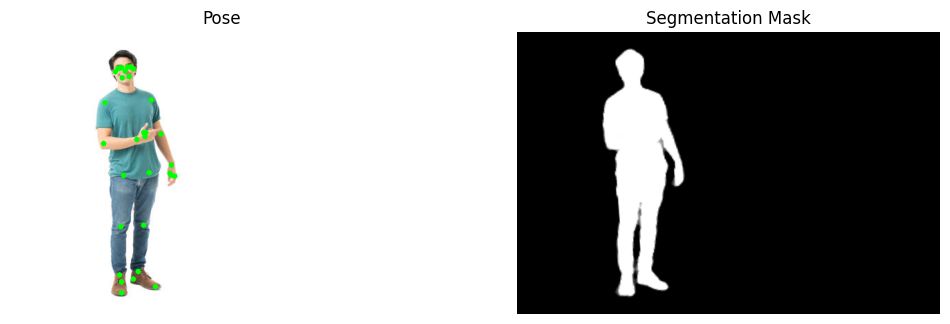

Saved: True
Path: /content/drive/MyDrive/Colab Notebooks/computer vision/Ultralytics YOLO/pose estimation/mediapipe_image_predictions/image1.jpg


In [42]:
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Load model
base_options = python.BaseOptions(
    model_asset_path="pose_landmarker_full.task"
)

options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    output_segmentation_masks=True,   # 🔥 Enable segmentation
    num_poses=1
)

detector = vision.PoseLandmarker.create_from_options(options)

# Load image
image = cv2.imread(f"{project_path}/image.jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=image_rgb
)

# Run inference
result = detector.detect(mp_image)

# -----------------------------
# Draw pose landmarks
# -----------------------------
if result.pose_landmarks:
    for lm in result.pose_landmarks[0]:
        x = int(lm.x * image.shape[1])
        y = int(lm.y * image.shape[0])
        cv2.circle(image, (x, y), 4, (0, 255, 0), -1)

# -----------------------------
# Process segmentation mask
# -----------------------------
if result.segmentation_masks:
    mask = result.segmentation_masks[0].numpy_view()

    # Normalize mask to 0–255
    mask = (mask * 255).astype(np.uint8)

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.title("Pose")
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Segmentation Mask")
    plt.imshow(mask, cmap='gray')
    plt.axis("off")

    plt.show()

    success = cv2.imwrite(save_path, mask)

    print("Saved:", success)
    print("Path:", save_path)

In [43]:
import os

save_dir = f"{project_path}/mediapipe_image_predictions"
os.makedirs(save_dir, exist_ok=True)

save_path = f"{save_dir}/image2.jpg"

Saved: True
Path: /content/drive/MyDrive/Colab Notebooks/computer vision/Ultralytics YOLO/pose estimation/mediapipe_image_predictions/image2.jpg


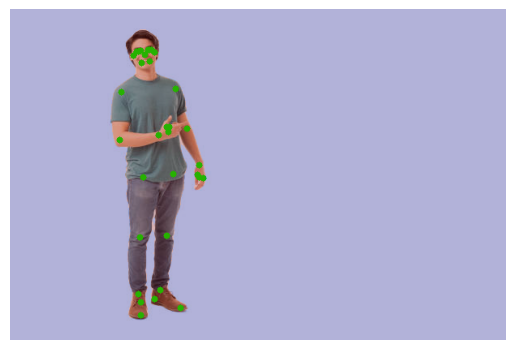

In [44]:
if result.segmentation_masks:
    mask = result.segmentation_masks[0].numpy_view()
    mask = (mask > 0.5).astype(np.uint8) * 255  # Threshold

    colored_mask = cv2.applyColorMap(mask, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(image, 0.7, colored_mask, 0.3, 0)

    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    success = cv2.imwrite(save_path, overlay)

    print("Saved:", success)
    print("Path:", save_path)

In [38]:
import cv2
import mediapipe as mp
import numpy as np
import time
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# -----------------------------
# Load Pose Landmarker Model
# -----------------------------
base_options = python.BaseOptions(
    model_asset_path="pose_landmarker_full.task"
)

options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
    output_segmentation_masks=True,
    num_poses=1,
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5,
    min_tracking_confidence=0.5
)

detector = vision.PoseLandmarker.create_from_options(options)

# -----------------------------
# Open Input Video
# -----------------------------
input_video = f"{project_path}/video1.mp4"
output_video = f"{project_path}/mediapipe_video_predictions/segmentation_output.mp4"

cap = cv2.VideoCapture(input_video)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

start_time = time.time()

print("Processing video...")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Correct MP Image creation
    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=frame_rgb
    )

    # Timestamp must be increasing (milliseconds)
    timestamp_ms = int((time.time() - start_time) * 1000)

    result = detector.detect_for_video(mp_image, timestamp_ms)

    # -----------------------------
    # Draw Segmentation Mask
    # -----------------------------
    if result.segmentation_masks:
        mask = result.segmentation_masks[0].numpy_view()

        # Convert probability mask → binary
        mask = (mask > 0.5).astype(np.uint8) * 255

        # Resize mask to match frame
        mask = cv2.resize(mask, (width, height))

        # Apply color map
        colored_mask = cv2.applyColorMap(mask, cv2.COLORMAP_JET)

        # Overlay
        frame = cv2.addWeighted(frame, 0.7, colored_mask, 0.3, 0)

    out.write(frame)

cap.release()
out.release()

print("Saved as:", output_video)

Processing video...
Saved as: /content/drive/MyDrive/Colab Notebooks/computer vision/Ultralytics YOLO/pose estimation/mediapipe_video_predictions/segmentation_output.mp4
